In [1]:
import numpy as np
import pandas as pd

In [2]:
from sklearn.datasets import make_classification
import numpy as np
X, y = make_classification(n_samples=100, n_features=2, n_informative=1,n_redundant=0,
                           n_classes=2, n_clusters_per_class=1, random_state=41,hypercube=False,class_sep=10)

In [3]:
import matplotlib.pyplot as plt

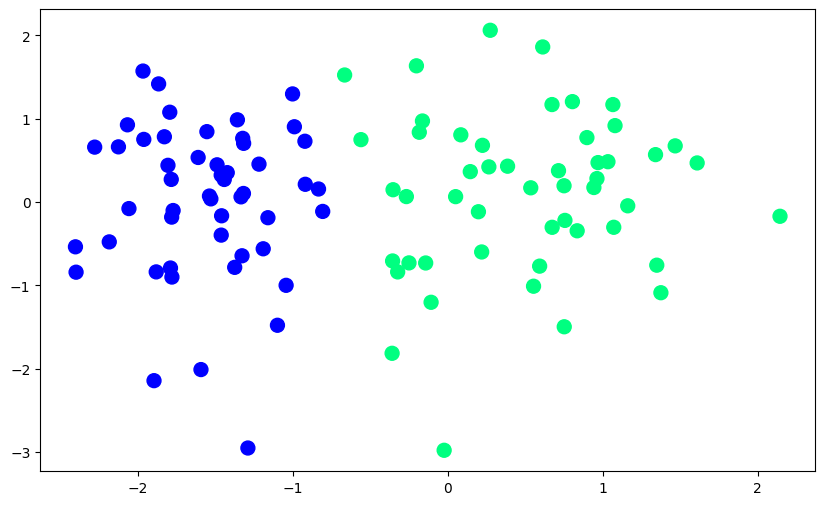

In [4]:
plt.figure(figsize=(10,6))
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)

In [9]:
print(type(X))
print(X.shape)
print(X[0])

<class 'numpy.ndarray'>
(100, 2)
[ 0.19924745 -0.11697552]


In [10]:
print(X[0].shape)
weights= np.ones(X.shape[1])
print(weights.shape)

(2,)
(2,)


In [14]:
def step(x):
    if x>=0:
        return 1
    return 0

In [27]:
def perceptron(X,y):
    lr= 0.1
    X= np.insert(X,0,1,axis=1)
    weights= np.ones(X.shape[1])
    for i in range(1000):
        j = np.random.randint(0,100)
        y_hat = step(np.dot(X[j], weights))
        weights = weights + lr *(y[j]- y_hat)*X[j]
    return weights
    

In [29]:
weights = perceptron(X,y)
weights

array([0.9       , 1.3516696 , 0.10630903])

In [32]:
intercept_ = weights[0]
coef_ = weights[1:]

In [33]:
m = -(coef_[0]/coef_[1])
b = -(intercept_/coef_[1])

In [34]:
x_input = np.linspace(-3,3,100)
y_input = m*x_input + b

(-3.0, 2.0)

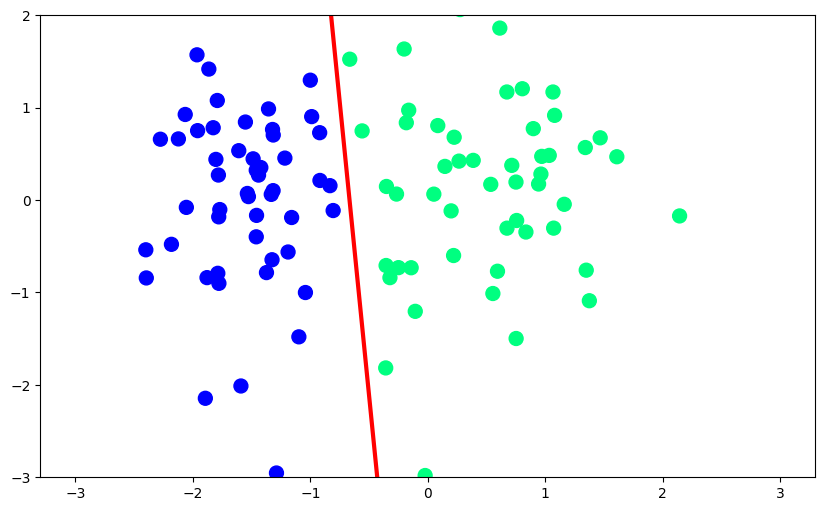

In [35]:
plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)

In [36]:
def perceptron(X,y):
    
    m = []
    b = []
    
    X = np.insert(X,0,1,axis=1)
    weights = np.ones(X.shape[1])
    lr = 0.1
    
    for i in range(200):
        j = np.random.randint(0,100)
        y_hat = step(np.dot(X[j],weights))
        weights = weights + lr*(y[j]-y_hat)*X[j]
        
        m.append(-(weights[1]/weights[2]))
        b.append(-(weights[0]/weights[2]))
        
    return m,b

In [37]:
m,b = perceptron(X,y)

In [38]:
%matplotlib notebook
from matplotlib.animation import FuncAnimation
import matplotlib.animation as animation

In [39]:
fig, ax = plt.subplots(figsize=(9,5))

x_i = np.arange(-3, 3, 0.1)
y_i = x_i*m[0] +b[0]
ax.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
line, = ax.plot(x_i, x_i*m[0] +b[0] , 'r-', linewidth=2)
plt.ylim(-3,3)
def update(i):
    label = 'epoch {0}'.format(i + 1)
    line.set_ydata(x_i*m[i] + b[i])
    ax.set_xlabel(label)
    # return line, ax

anim = FuncAnimation(fig, update, repeat=True, frames=200, interval=100)

<IPython.core.display.Javascript object>